In [1]:
from pathlib import Path

# General helpful packages for data analysis and visualization
import pandas as pd
import scanpy as sc
import seaborn as sns
from muon import atac as ac  # the module containing function for scATAC data processing
import matplotlib.pyplot as plt
import muon as mu

import sys
PROJECT_DIR = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER"
SRC_DIR = str(Path(PROJECT_DIR) / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
    
DEV_DIR = str(Path(PROJECT_DIR) / "dev")
if DEV_DIR not in sys.path:
    sys.path.insert(0, DEV_DIR)
    
import muon_preprocessing as muon_prep

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [ ]:
PROJECT_DIR=Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/")

RAW_DATA_DIR=Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/RAW_DATA")

STABILITY_CELL_SUBSAMPLE_DIR=Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/STABILITY_RAW_DATASETS")

DATASET_NAME="mESC_10x_raw"
SAMPLE_NAME="E7.5_rep1"
PROCESSED_DATA_NAME=f"mESC_{SAMPLE_NAME}_muon_class_test"
ORGANISM_CODE="mm10"

TSS_PATH=f"{PROJECT_DIR}/data/genome_data/genome_annotation/{ORGANISM_CODE}/gene_tss.bed"
TF_LIST_FILE=""

RAW_DATA_DIR=f"{PROJECT_DIR}/data/raw/{DATASET_NAME}/"
PROCESSED_DATA_DIR=f"{PROJECT_DIR}/data/processed/{PROCESSED_DATA_NAME}"

FRAG_PATH=f"{RAW_DATA_DIR}/{SAMPLE_NAME}/fragments.sorted.tsv.gz"

RNA_COUNT_FILE=""
ATAC_COUNT_FILE=""

RAW_H5_FILE=""

SAMPLE_DATA_DIR = Path(RAW_DATA_DIR) / SAMPLE_NAME
SAMPLE_PROCESSED_DATA_DIR = Path(PROCESSED_DATA_DIR) / SAMPLE_NAME

In [120]:
tss_path = Path(TSS_PATH)
rna_count_file = Path(RNA_COUNT_FILE) if RNA_COUNT_FILE else None
atac_count_file = Path(ATAC_COUNT_FILE) if ATAC_COUNT_FILE else None
raw_h5_file = Path(RAW_H5_FILE) if RAW_H5_FILE else None
tf_list_file = Path(TF_LIST_FILE) if TF_LIST_FILE else None
frag_path = Path(FRAG_PATH) if FRAG_PATH else None

In [36]:
filtering_setting_df = pd.read_csv(PROJECT_DIR / "dev" / "notebooks" / "muon_preprocessing" /"qc_filtering_settings.tsv", sep="\t")
sample_filtering_settings = filtering_setting_df[filtering_setting_df["Sample"] == SAMPLE_NAME]    

# ----- RNA QC thresholds -----
MIN_CELLS_PER_GENE = muon_prep.get_threshold(sample_filtering_settings, "Min Cells per Gene")
MIN_GENES_PER_CELL = muon_prep.get_threshold(sample_filtering_settings, "Min Genes per Cell")
MAX_GENES_PER_CELL = muon_prep.get_threshold(sample_filtering_settings, "Max Genes per Cell")
MIN_TOTAL_COUNTS = muon_prep.get_threshold(sample_filtering_settings, "Min Total Counts")
MAX_TOTAL_COUNTS = muon_prep.get_threshold(sample_filtering_settings, "Max Total Counts")
MAX_PCT_COUNTS_MT = muon_prep.get_threshold(sample_filtering_settings, "Max Pct MT")

# ----- ATAC QC thresholds -----
MIN_CELLS_PER_PEAK = muon_prep.get_threshold(sample_filtering_settings, "Min Cells per Peak")
MIN_PEAKS_PER_CELL = muon_prep.get_threshold(sample_filtering_settings, "Min Peaks per Cell")
MAX_PEAKS_PER_CELL = muon_prep.get_threshold(sample_filtering_settings, "Max Peaks per Cell")
MIN_TOTAL_PEAK_COUNTS = muon_prep.get_threshold(sample_filtering_settings, "Min Total Peak Counts")
MAX_TOTAL_PEAK_COUNTS = muon_prep.get_threshold(sample_filtering_settings, "Max Total Peak Counts")

if not SAMPLE_PROCESSED_DATA_DIR.exists():
    SAMPLE_PROCESSED_DATA_DIR.mkdir(parents=True)

Min Cells per Gene: 20
Min Genes per Cell: 1500
Max Genes per Cell: 6000
Min Total Counts: 1000
Max Total Counts: 25000
Max Pct MT: 20
Min Cells per Peak: 1
Min Peaks per Cell: 500
Max Peaks per Cell: 25000
Min Total Peak Counts: 1000
Max Total Peak Counts: 60000


In [ ]:
mdata, frag_path = muon_prep.load_raw_data(SAMPLE_NAME, SAMPLE_DATA_DIR, rna_count_file, atac_count_file, raw_h5_file)

mdata.write(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu")

Loading data for sample E7.5_rep1 from /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1...
  - atac_peak_annotation.tsv
  - fragments.sorted.tsv.gz.tbi
  - fragments.sorted.tsv.gz
  - features.tsv.gz
  - fragments.tsv.gz
  - barcodes.tsv.gz
  - matrix.mtx.gz


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:

In [123]:
import importlib
importlib.reload(muon_prep)

<module 'muon_preprocessing' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/muon_preprocessing.py'>

In [124]:
data_processor = muon_prep.MudataProcessor(
    mdata=mdata,
    processed_data_dir=SAMPLE_PROCESSED_DATA_DIR,
    sample_name=SAMPLE_NAME,
    tss_path=tss_path,
    tf_list_file=tf_list_file
)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [ ]:
data_processor.save_stability_subsamplings(
    raw_mdata=mdata,
    subsampling_dir = STABILITY_CELL_SUBSAMPLE_DIR / DATASET_NAME / SAMPLE_NAME,
    pct_subsample=0.7,
    num_subsamples=10
)

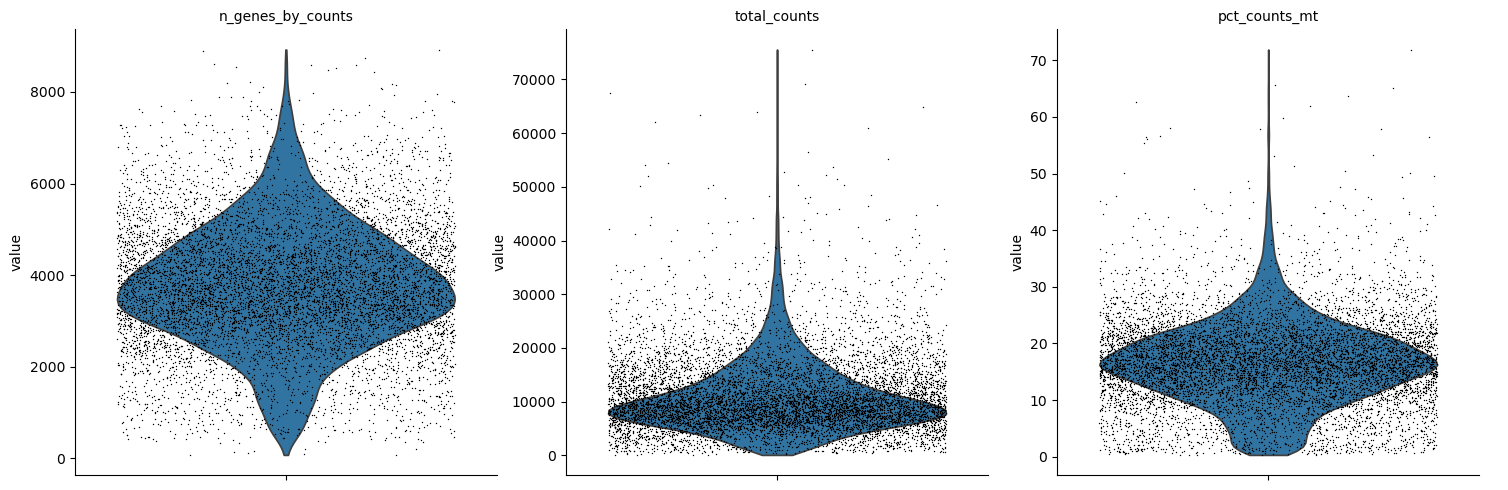

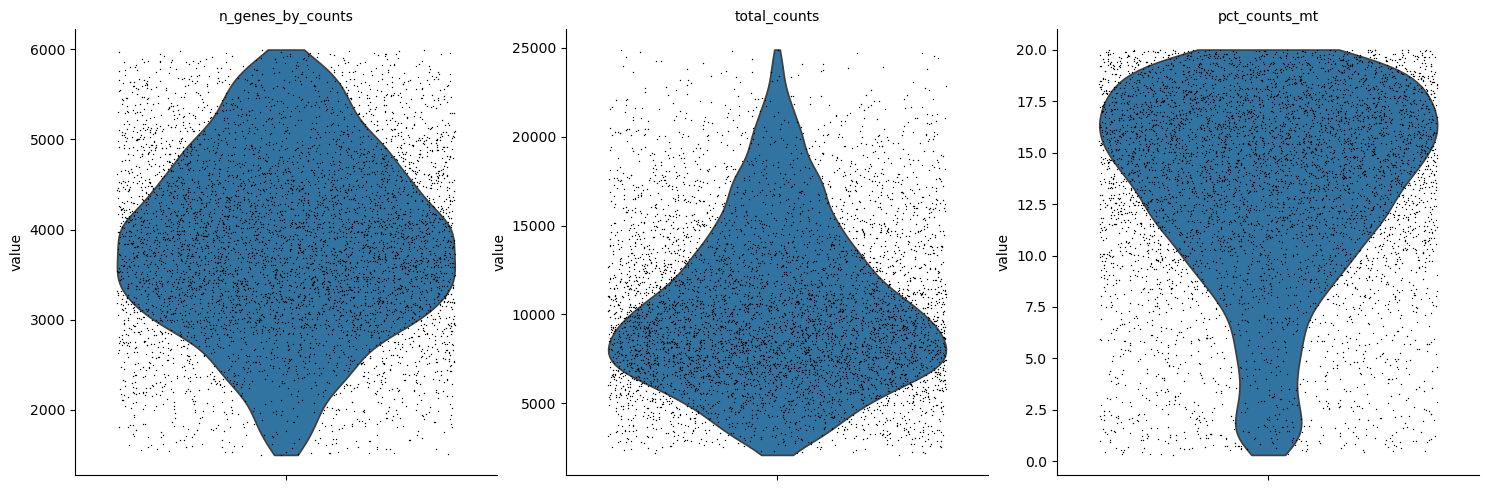

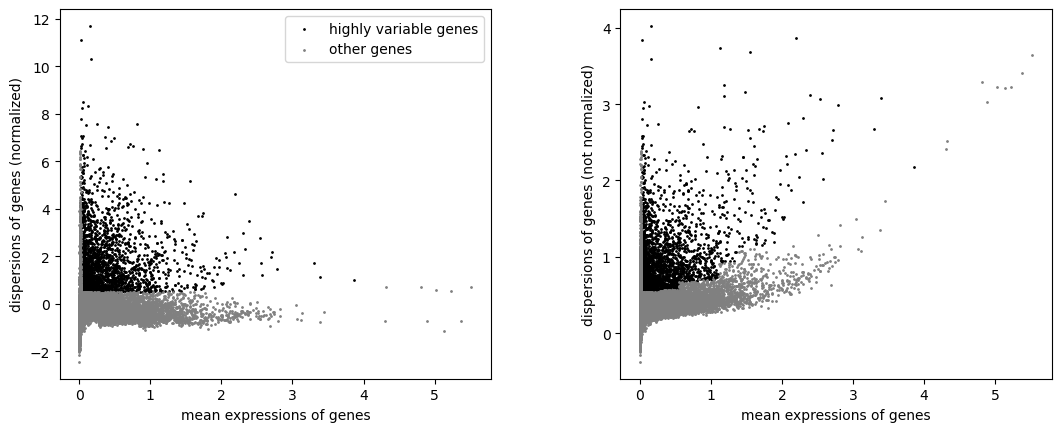

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
# RNA QC and Preprocessing
data_processor.rna_qc_filter(
    min_cells_per_gene = MIN_CELLS_PER_GENE,
    min_genes_per_cell = MIN_GENES_PER_CELL,
    max_genes_per_cell = MAX_GENES_PER_CELL,
    min_total_counts_per_cell = MIN_TOTAL_COUNTS,
    max_total_counts_per_cell = MAX_TOTAL_COUNTS,
    max_pct_counts_mt = MAX_PCT_COUNTS_MT,
    norm_target_sum = 1e4,
    min_rna_disp = 0.5,
    filter_hvgs = False,
    tf_list_file = None,
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "rna_qc",
    )

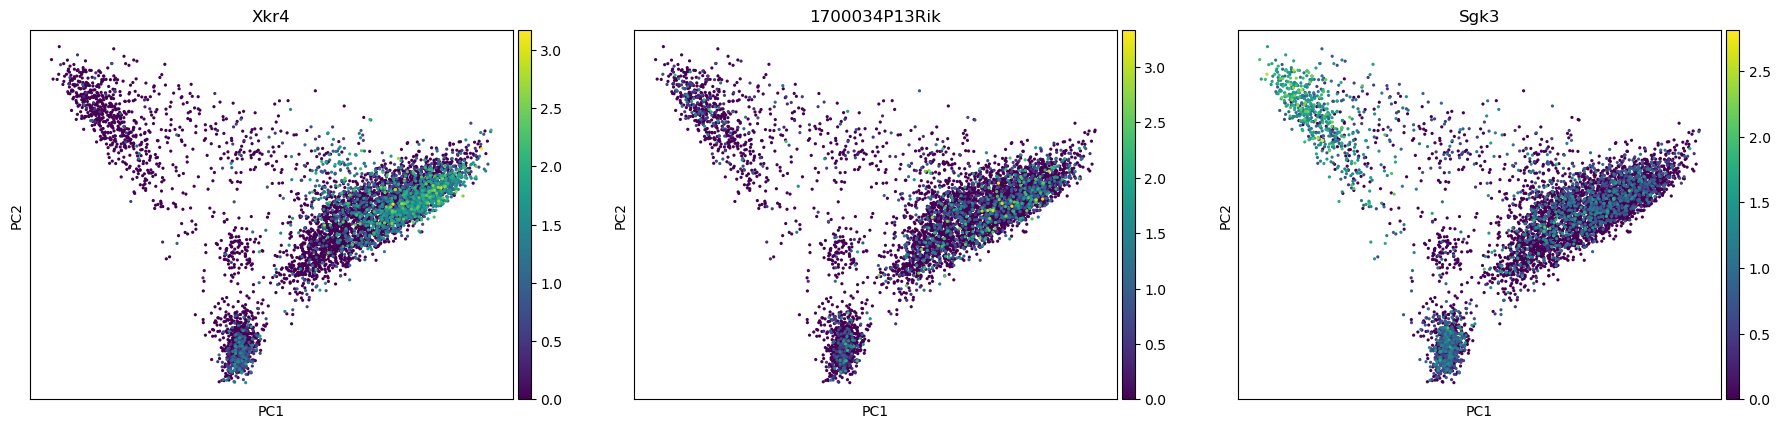

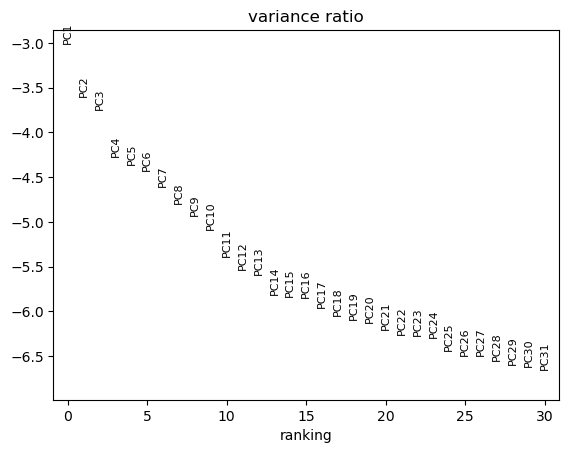

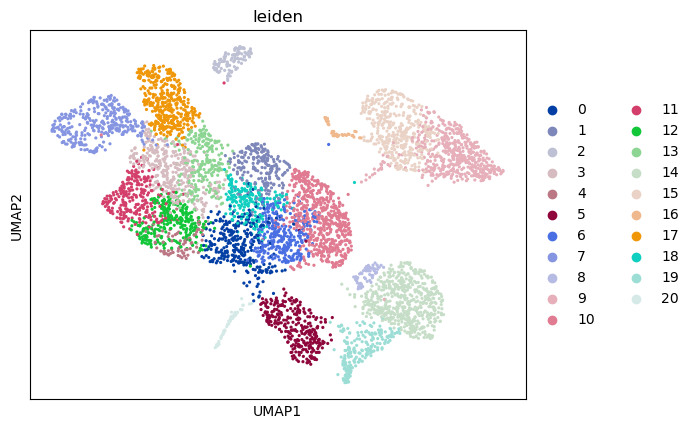

In [ ]:
data_processor.rna_pca_and_neighbors(
    data_processor.rna, 
    n_pcs=20,
    n_neighbors=10,
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "rna_qc",
    )

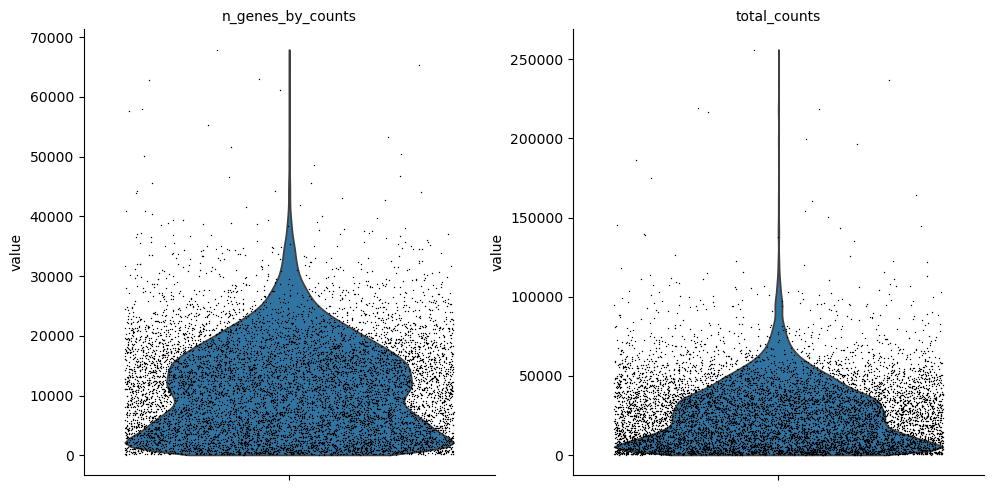

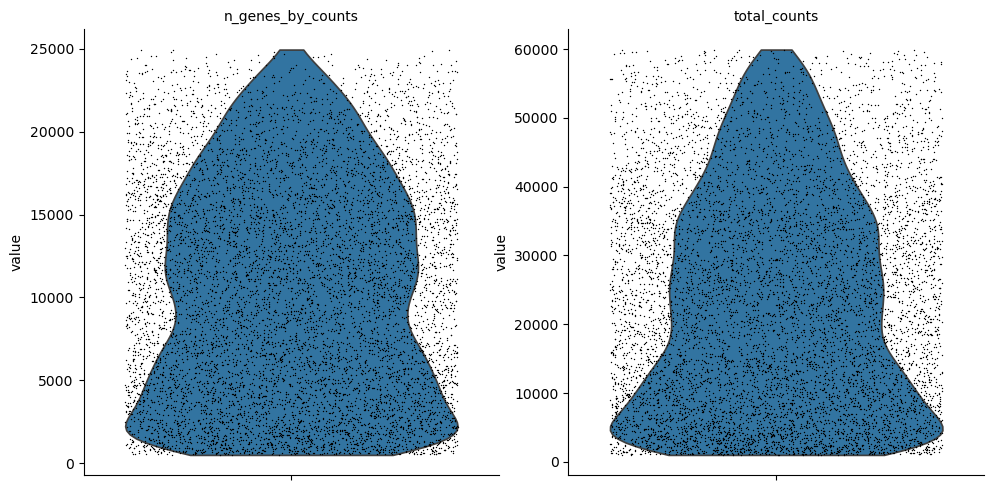

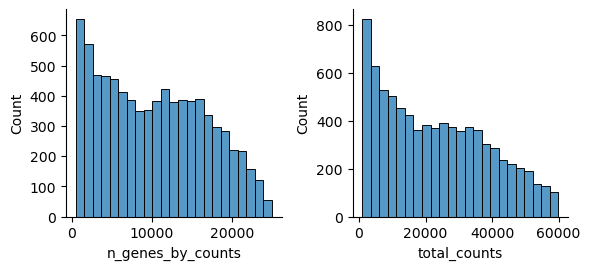

/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/muon_preprocessing.py:502: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(self.atac, counts_per_cell_after=1e4)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


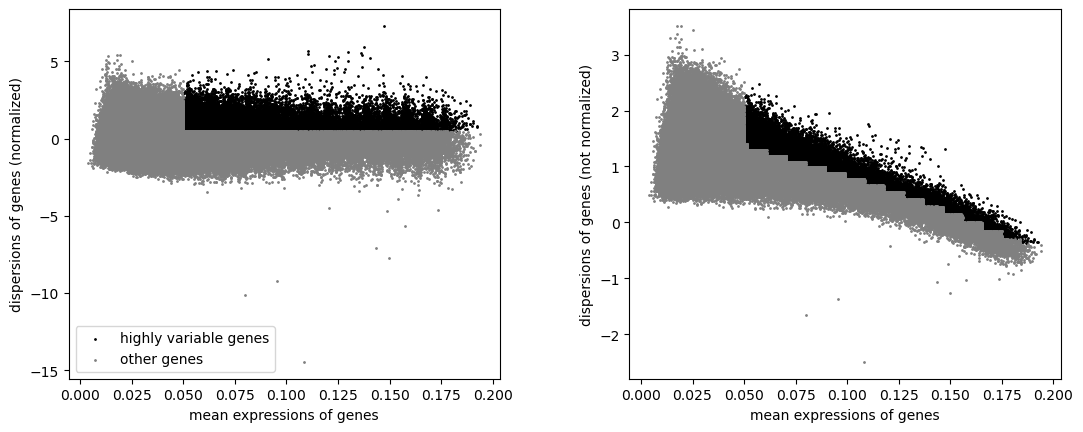

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


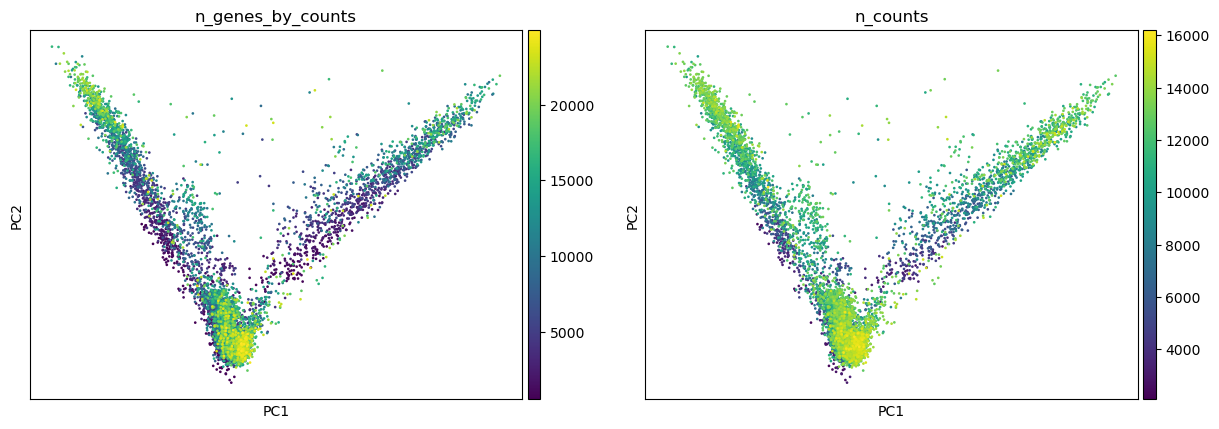

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_atac/tools.py:118: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  pa.loc[pa.distance.isnull(), "distance"] = ""


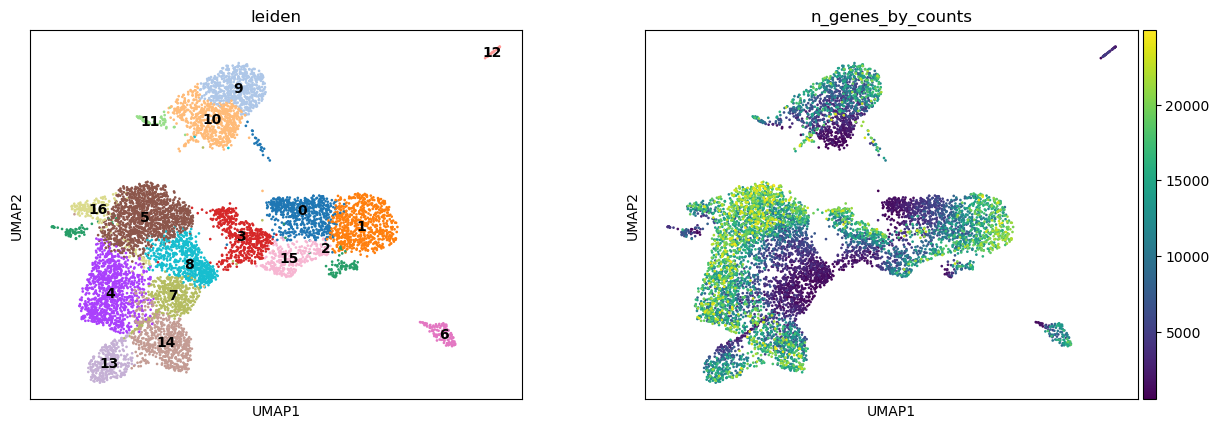

In [127]:
# ATAC QC and Preprocessing
data_processor.atac_qc_filter(
    min_cells_per_peak=MIN_CELLS_PER_PEAK,
    min_peaks_per_cell=MIN_PEAKS_PER_CELL,
    max_peaks_per_cell=MAX_PEAKS_PER_CELL,
    min_total_counts_per_cell=MIN_TOTAL_PEAK_COUNTS,
    max_total_counts_per_cell=MAX_TOTAL_PEAK_COUNTS,
    min_atac_disp=0.5,
    promoter_upstream=1000,
    promoter_downstream=100,
    distal_max=200_000,
    filter_hvgs=False,
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "atac_qc",
    )

In [130]:
data_processor.nucleosome_signal(
    frag_path=frag_path, 
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "atac_qc"
    )

Found index: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/fragments.sorted.tsv.gz.tbi
['GL456210.1', 'GL456211.1', 'GL456212.1', 'GL456216.1', 'GL456219.1', 'GL456221.1', 'GL456233.1', 'GL456350.1', 'GL456354.1', 'JH584292.1', 'JH584295.1', 'JH584296.1', 'JH584297.1', 'JH584299.1', 'JH584304.1', 'chr1', 'chr10', 'chr11', 'chr12', 'chr13']


Reading Fragments: 100%|██████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:04<00:00, 229848.72it/s]


In [129]:
data_processor.tss_enrichment(
    frag_path=frag_path, 
    n_tss=500, 
    extend_upstream=1000, 
    extend_downstream=1000,
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "atac_qc"
    )


Fetching Regions...: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 105/105 [00:04<00:00, 21.27it/s]
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


In [131]:
# Save the processed data
muon_prep.save_processed_data(data_processor.mdata, SAMPLE_PROCESSED_DATA_DIR)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Loaded view='rna' group='group1' with N=5199 samples and D=2453 features...
Loaded view='atac' group='group1' with N=5199 samples and D=18746 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Li

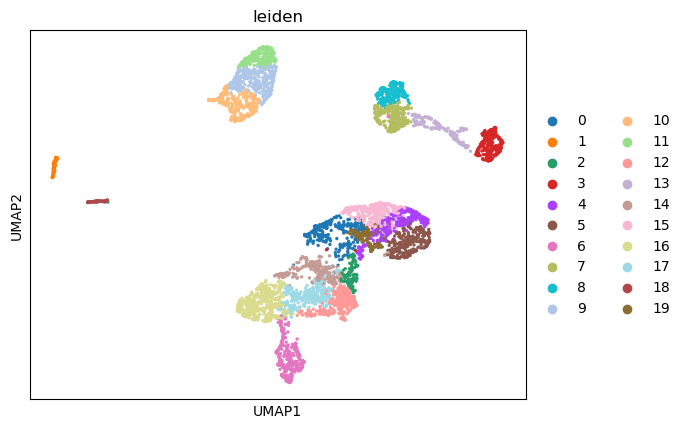

In [132]:
# Integrate the RNA and ATAC modalities using MOFA+
muon_prep.integrate_rna_atac(
    data_processor.mdata, 
    SAMPLE_PROCESSED_DATA_DIR, 
    SAMPLE_NAME, 
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "integration"
    )

In [133]:
# Create metacells
muon_prep.create_metacells(data_processor.mdata, SAMPLE_PROCESSED_DATA_DIR, hops=2)